In [1]:
!git clone https://github.com/marcusklasson/GroceryStoreDataset.git
!pip install image-classifiers

Cloning into 'GroceryStoreDataset'...
remote: Enumerating objects: 6559, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (229/229), done.
remote: Total 6559 (delta 45), reused 35 (delta 35), pack-reused 6295 (from 2)
Receiving objects: 100% (6559/6559), 116.26 MiB | 14.45 MiB/s, done.
Resolving deltas: 100% (275/275), done.
Updating files: 100% (5717/5717), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 6.1 MB/s eta 0:00:00


In [2]:
import os
import random
import warnings


import numpy as np
import pandas as pd
import cv2


import seaborn as sns
import matplotlib.pyplot as plt

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from classification_models.tfkeras import Classifiers

# Machine Learning Utility (Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

warnings.filterwarnings('ignore')

# data mining

In [12]:
#ROOT_DIR = "/content/GroceryStoreDataset/dataset/" # The base directory where the images and CSVs are stored
ROOT_DIR = "/home/tomas/Desktop/CV/GroceryStoreDataset-master/dataset"
# Loads the 'classes.csv' of the dataset metadata
classes_df = pd.read_csv(os.path.join(ROOT_DIR, "classes.csv"))
print(f"Shape: {classes_df.shape}") 
print(f"Unique Classes: {classes_df['Class ID (int)'].unique()}") # Checks how many distinct categories exist
classes_df.head() # Shows the first 5 rows of the pandas dataframe of the metadata 

Shape: (81, 6)
Unique Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80]


,Class Name (str),Class ID (int),Coarse Class Name (str),Coarse Class ID (int),Iconic Image Path (str),Product Description Path (str)
0,Golden-Delicious,0,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Go...,/iconic-images-and-descriptions/Fruit/Apple/Go...
1,Granny-Smith,1,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Gr...,/iconic-images-and-descriptions/Fruit/Apple/Gr...
2,Pink-Lady,2,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Pi...,/iconic-images-and-descriptions/Fruit/Apple/Pi...
3,Red-Delicious,3,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Re...,/iconic-images-and-descriptions/Fruit/Apple/Re...
4,Royal-Gala,4,Apple,0,/iconic-images-and-descriptions/Fruit/Apple/Ro...,/iconic-images-and-descriptions/Fruit/Apple/Ro...


In [13]:
def process_dataframe_fixed(df, root_dir): #creare the right path for the data loading
    df['path'] = df['path'].apply(lambda x: os.path.join(root_dir, x)) #directly inside the dataframe pandas
    df['fine_label'] = df['fine_label'].astype(str)
    return df
#create all the dataset
train_df = pd.read_csv(os.path.join(ROOT_DIR, "train.txt"), header=None, sep=",", names=['path', 'fine_label', 'coarse_label'])
val_df   = pd.read_csv(os.path.join(ROOT_DIR, "val.txt"), header=None, sep=",", names=['path', 'fine_label', 'coarse_label'])
test_df  = pd.read_csv(os.path.join(ROOT_DIR, "test.txt"), header=None, sep=",", names=['path', 'fine_label', 'coarse_label'])
print(test_df.head(1))
#keep only final_label
train_df.drop(columns=["coarse_label"], inplace=True)
val_df.drop(columns=["coarse_label"], inplace=True)
test_df.drop(columns=["coarse_label"], inplace=True)
print(test_df.head(1))
train_df = process_dataframe_fixed(train_df, ROOT_DIR)
val_df = process_dataframe_fixed(val_df, ROOT_DIR)
test_df = process_dataframe_fixed(test_df, ROOT_DIR)

print(f"Labels class in Train: {train_df['fine_label'].nunique()}")
print(f"Labels class in Val:   {val_df['fine_label'].nunique()}")
print(f"Labeles class in Test:  {test_df['fine_label'].nunique()}")

                                                path  fine_label  coarse_label
0  test/Fruit/Apple/Golden-Delicious/Golden-Delic...           0             0
                                                path  fine_label
0  test/Fruit/Apple/Golden-Delicious/Golden-Delic...           0
Labels class in Train: 81
Labels class in Val:   60
Labeles class in Test:  81


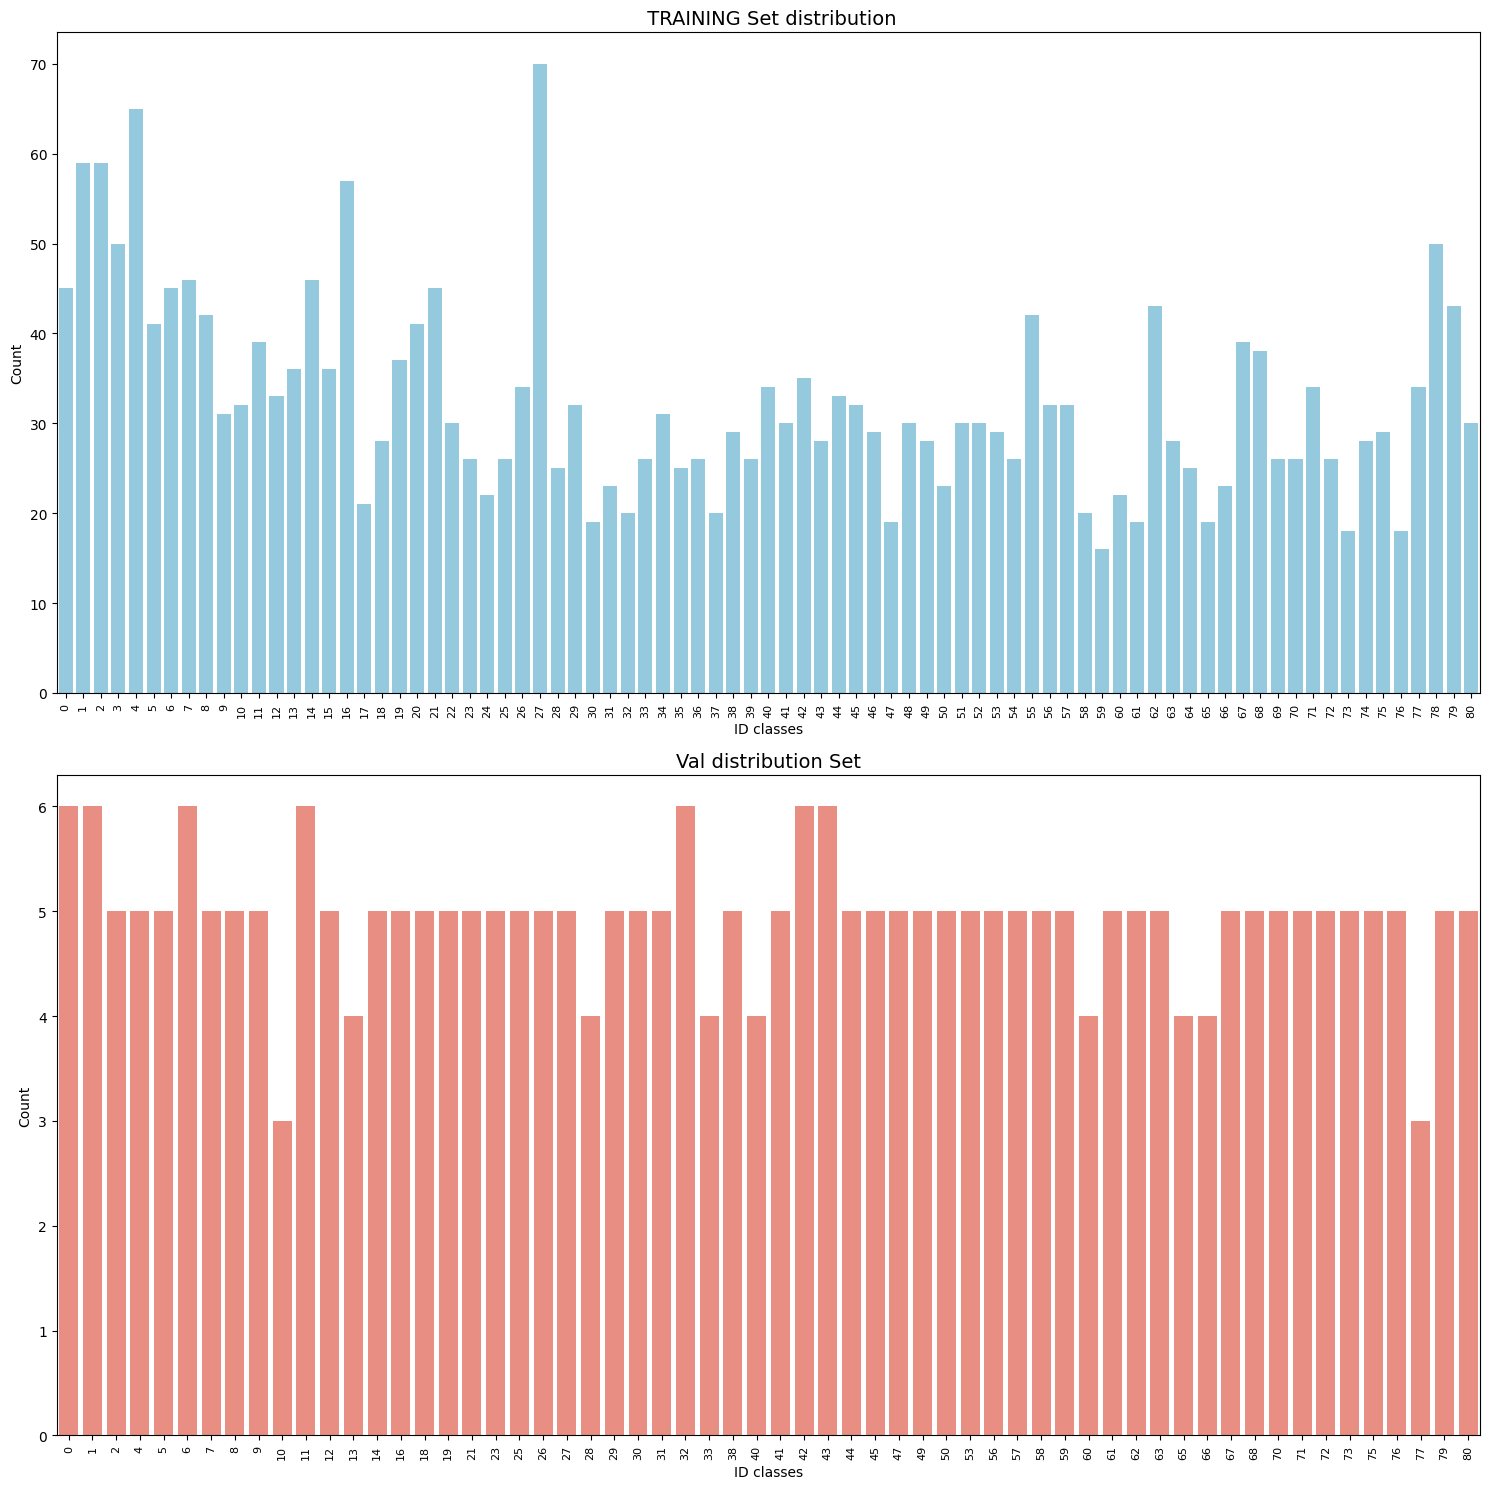

unique class Train: 81
unique class Val:   60


In [5]:
#creating the hist of the class label frequencies
def plot_dist(df, ax, title, color):
    order = sorted(df['fine_label'].unique(), key=int) #label ordering
    sns.countplot(data=df, x='fine_label', order=order, ax=ax, color=color) #manage the hist by seaborn
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("ID classes", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=8)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 15))
plot_dist(train_df, ax1, " TRAINING Set distribution", "skyblue")
plot_dist(val_df, ax2, "Val distribution Set", "salmon")
plt.tight_layout()
plt.show()

print(f"unique class Train: {train_df['fine_label'].nunique()}")
print(f"unique class Val:   {val_df['fine_label'].nunique()}")


In [6]:
df_combined = pd.concat([train_df, val_df], ignore_index=True) #merge the two dataset val and train because i want recreate the entire dataset
lista_classi = sorted(df_combined['fine_label'].unique().tolist()) #create a list of the classes 
NUM_CLASSES = len(lista_classi)

train_df_new, val_df_new = train_test_split(
    df_combined,
    test_size=0.20, #val is 20%
    stratify=df_combined['fine_label'], # keep the same class label distribution between val and train
    random_state=42
)

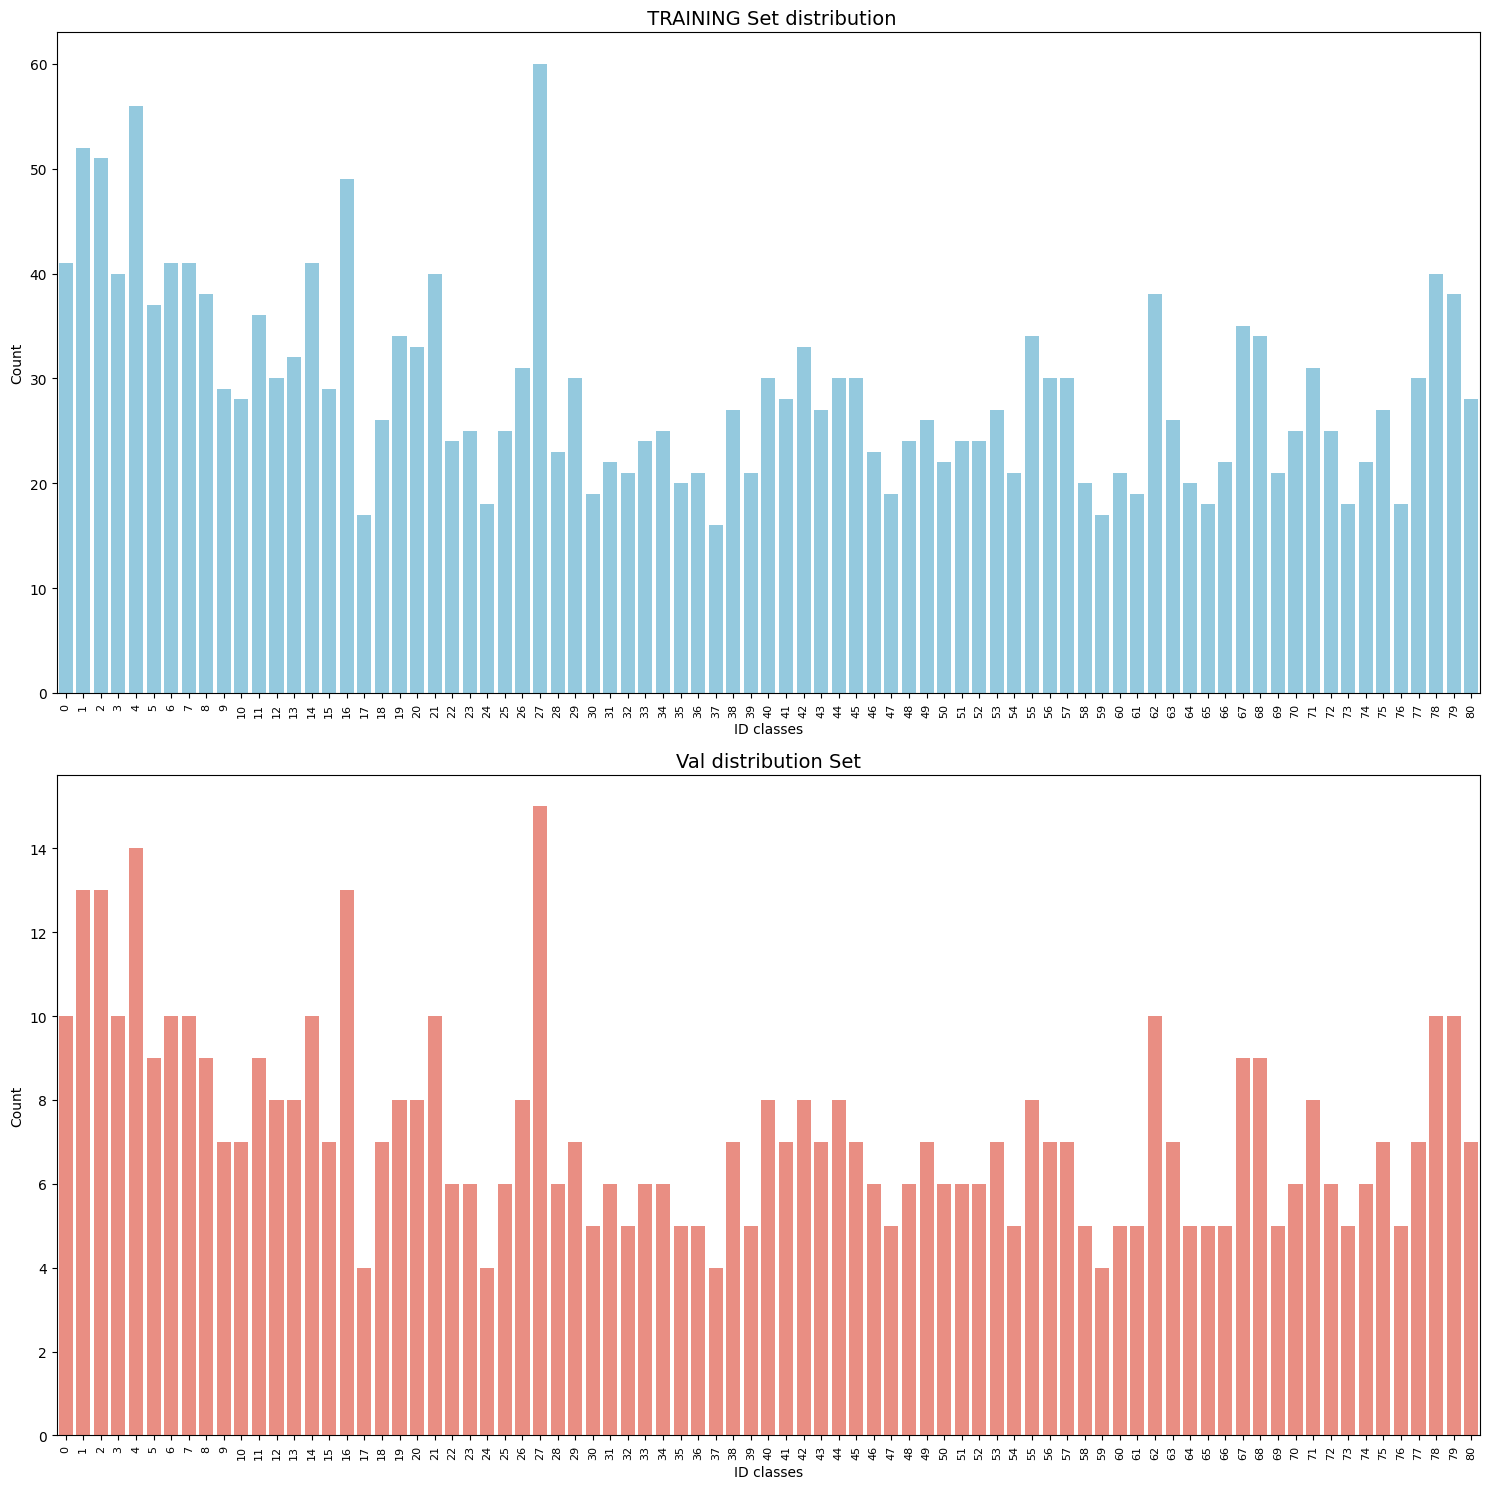

Classi uniche in Train: 81
Classi uniche in Val:   81


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 15))
plot_dist(train_df_new, ax1, " TRAINING Set distribution", "skyblue")
plot_dist(val_df_new, ax2, "Val distribution Set", "salmon")
plt.tight_layout()
plt.show()

print(f"Classi uniche in Train: {train_df_new['fine_label'].nunique()}")
print(f"Classi uniche in Val:   {val_df_new['fine_label'].nunique()}")

# first task

In [9]:
IMG_RAW_H, IMG_RAW_W = 256, 256 #original input images shape
IMG_CROP_H, IMG_CROP_W = 224, 224 #image shape after a random crop as data augmentation
CHANNELS = 3 #image channels RGB
BATCH_SIZE = 64 #weight update after 64 images
EPOCHS = 60 #number of epoch (an entier input data elaboration by CNN)
#Rescale data to the range [0,1] using ImageDataGenerator. This normalizes the input features, 
#The loss function is sensitive to variations in feature scales; inconsistent scaling can making convergence slow or unstable
# ImageDataGenerator manage the images loading and the right RGB reppresentation 
# working in batch allow a good memory usage !!!!
datagen = ImageDataGenerator(rescale=1./255)
#now define the data batch stream into the model
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df_new,
    x_col='path',
    y_col='fine_label',
    target_size=(IMG_RAW_H, IMG_RAW_W),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # one hot encoding for the class labels
    classes=lista_classi,
    shuffle=True #i don't want a model with a bias for the images order
)
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df_new,
    x_col='path', #column with files path
    y_col='fine_label', #column with labels
    target_size=(IMG_RAW_H, IMG_RAW_W), #the crop will be inside the model with other data augmentation
    batch_size=BATCH_SIZE, #define the data batch for the data generator stream inside the model
    class_mode='categorical',
    classes=lista_classi,
    shuffle=False #for validation consistency
)
# FOR UN BALANCE DATASET AS MINE (some classes own many examples that others)
train_labels = train_generator.classes #labels extaction
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
#class with less sample provide a bigger weight update in the trianing, allow a better learning for unbalance dataset
#execute weight based on the label frequency
dict_weights = dict(enumerate(weights)) #weight dictionary for the model fit

Found 2348 validated image filenames belonging to 81 classes.
Found 588 validated image filenames belonging to 81 classes.


64 - 64
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]


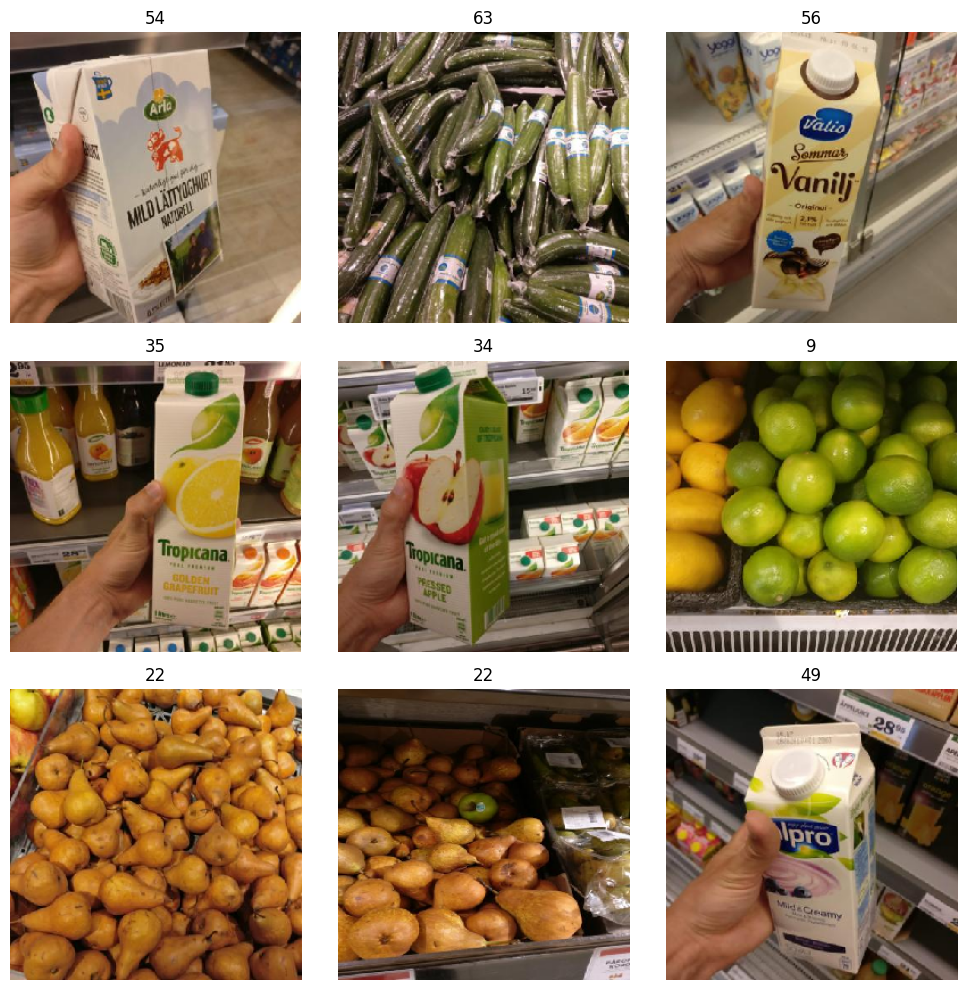

64


In [11]:

images, labels = next(train_generator) #take a batch of 64 images and the one hot encode
print(f"{len(images)} - {len(labels)}")
print(labels[0])
n_images = 9 #show up 9 images
plt.figure(figsize=(10, 10))
for i in range(n_images):
    plt.subplot(3, 3, i + 1) #setting
    plt.imshow(images[i]) #image in 256 X 256 and [0, 1] scaling show up 
    label_idx = labels[i].argmax() #label in one hot encode -> take the label index 
    label_name = lista_classi[label_idx] #select the right class label
    plt.title(label_name)
    plt.axis('off')
plt.tight_layout()
plt.show()
print(len(images))

In [10]:
def build_final_model(input_shape_raw, crop_height, crop_width, num_classes):
    """
    Constructs a Deep CNN for image classification.
    Key Design Principles:
    - 3x3 conv S=1, P=1 zero pad
    - Same Padding (by default zero padding into conv layers ): Ensures convolutional layers maintain spatial dimensions.
    - Max Pooling: Dedicated downsampling (2x2, stride 2) to reduce spatial resolution by half.
    - Batch Normalization: Standardizes activations (mean ≈ 0, var ≈ 1) to stabilize gradients and accelerate convergence.
    - Global Average Pooling: Replaces 'Flatten' for better parameter efficiency and  spatial invariance before the classification head.
    Its reduce the model parameters
    """
    # --- 1. INPUT LAYER ---
    # Accepts raw high-resolution images (e.g., 256x256x3)
    inputs = layers.Input(shape=input_shape_raw) 
    # --- 2. GPU-ACCELERATED DATA AUGMENTATION to avoid over fitting---
    # Executed within the model pipeline for maximum throughput.
    # Note: These layers are only active during 'training' mode.
    x = layers.RandomCrop(crop_height, crop_width)(inputs) # Focus on sub-regions to increase variance
    x = layers.RandomFlip("horizontal")(x)                # Horizontal symmetry invariance
    x = layers.RandomRotation(0.2)(x)                     # Invariance to slight camera tilts
    x = layers.RandomContrast(0.1)(x)                     # Robustness to lighting conditions
    x = layers.RandomTranslation(0.1, 0.1)(x)             # Invariance to object positioning
    #The receptive field of the neurons increases with model depth. Specifically, 
    #MaxPooling operations at the end of each stage effectively double the receptive field relative to the input image,
    #allowing deeper layers to capture more global, semantic context.
    
    # --- 3. FEATURE EXTRACTION (The Backbone) ---
    # Block 1: Low-level features (Simple edges and color blobs)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x) 
    x = layers.MaxPooling2D((2, 2))(x) # Spatial reduction: 112x112
    
    # Block 2: Mid-level features (Basic shapes and orientations)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Spatial reduction: 56x56
    
    # Block 3: High-level features (Complex textures)
    # Stacked convolutions increase non-linearity and receptive field size.
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Spatial reduction: 28x28
    
    # Block 4: Abstract features (Object parts)
    x = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Spatial reduction: 14x14
    
    # Block 5: Deep semantic features (Class-specific indicators)
    x = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Spatial reduction: 7x7
    
    # --- 4. CLASSIFICATION HEAD ---
    # Global Average Pooling (GAP) collapses spatial dimensions into a single feature vector.
    # This prevents the "parameter explosion" typically caused by large Dense layers.
    x = layers.GlobalAveragePooling2D()(x)
    # Fully connected layer with L2 Regularization to penalize extreme weights (prevents overfitting).
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    # Dropout (50% rate) prevents co-adaptation by forcing the network to learn redundant representations.
    x = layers.Dropout(0.5)(x)
    # Final Layer: Softmax converts raw logits into a probability distribution over the target classes.
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    #create the model by the input and output layers connection
    return models.Model(inputs, outputs)

In [11]:
# --- MODEL INITIALIZATION ---
# Instantiate the architecture with defined dimensions and class count
model = build_final_model( #build up the model 
    input_shape_raw=(IMG_RAW_H, IMG_RAW_W, CHANNELS),
    crop_height=IMG_CROP_H,
    crop_width=IMG_CROP_W,
    num_classes=NUM_CLASSES
)
model.summary()

# --- COMPILATION ---
model.compile(
    # learning rate of 0.0004  conservative 
    optimizer=optimizers.Adam(learning_rate=0.0004), 
    
    # Label Smoothing (0.1) encourages the model to be less 'confident' and 
    # more adaptable, improving generalization and reducing over confidence of the model
    # we are going to smooth the loss target, instead [1, 0, 0] ->  [0.9,0.033,0.033]
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- TRAINING STRATEGY (CALLBACKS) ---
callbacks_list = [
    # EARLY STOPPING: Halts training if validation accuracy plateaus for 15 epochs
    # 'restore_best_weights' ensures we keep the optimal version of the model
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True, 
        verbose=1
    ),
    # LEARNING RATE DECAY: If validation loss stops improving for 5 epochs, 
    # reduce the learning rate by 80% (factor=0.2). This allows the optimizer 
    # to perform 'fine-tuning' as it approaches a local minimum. It's avoid the local minimum fluttuation
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]
# --- MODEL TRAINING ---
# Class weights are applied to the loss function to handle dataset imbalance
# By amplifying the loss for rare classes, we force the backpropagation 
# to update weights more aggressively for underrepresented categories, 
# preventing the model from ignoring them in favor of the majority class.
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list,
    class_weight=dict_weights 
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_crop (RandomCrop)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 512)    │         2,04

 Total params: 9,535,697 (36.38 MB)

 Trainable params: 9,530,193 (36.35 MB)

 Non-trainable params: 5,504 (21.50 KB)

Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.0860 - loss: 18.6169 - val_accuracy: 0.0119 - val_loss: 16.4888 - learning_rate: 4.0000e-04
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 30s 808ms/step - accuracy: 0.2448 - loss: 13.8125 - val_accuracy: 0.0085 - val_loss: 14.2017 - learning_rate: 4.0000e-04
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 32s 861ms/step - accuracy: 0.3174 - loss: 10.6558 - val_accuracy: 0.0085 - val_loss: 11.5607 - learning_rate: 4.0000e-04
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 824ms/step - accuracy: 0.4036 - loss: 8.2824 - val_accuracy: 0.0153 - val_loss: 9.7848 - learning_rate: 4.0000e-04
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 832ms/step - accuracy: 0.4671 - loss: 6.5545 - val_accuracy: 0.0102 - val_loss: 9.2289 - learning_rate: 4.0000e-04
Epoch 6/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 832ms/step - accuracy: 0.5439 - loss: 5.2214 - val_accuracy: 0.0102 - val_loss: 9.1490 - learning_rate: 4.0000e-04
Epoch 7/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 830ms/step - 

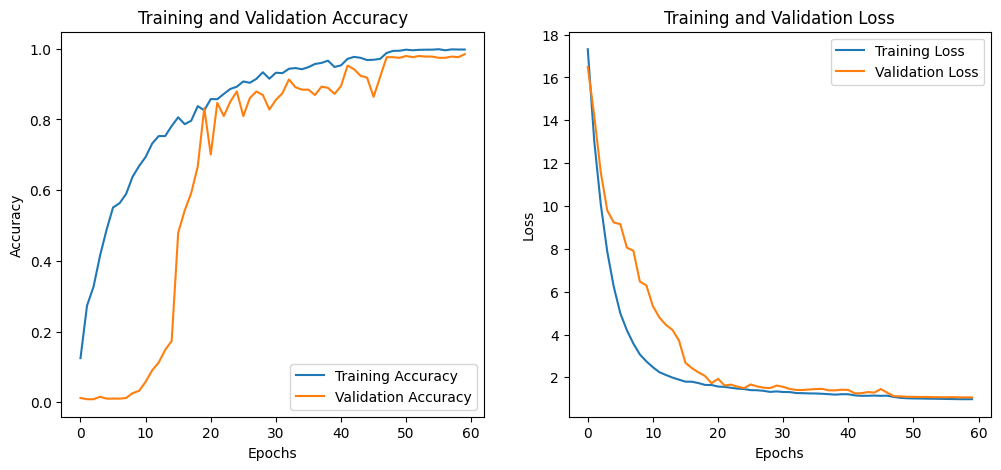

In [12]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))
    plt.figure(figsize=(12, 5))

    #  Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    #  Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.show()

plot_history(history)

# second task

In [ ]:
IMG_RAW_H, IMG_RAW_W = 256, 256
# Target dimensions after internal cropping (matches standard ResNet input)
IMG_CROP_H, IMG_CROP_W = 224, 224
CHANNELS = 3
BATCH_SIZE = 64
EPOCHS = 60
# Loading ResNet18 classifier and its specific preprocessing requirements.
ResNet18, preprocess_input = Classifiers.get('resnet18')
# use the specific ResNet preprocessing function 
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df_new,
    x_col='path',
    y_col='fine_label',
    target_size=(IMG_RAW_H, IMG_RAW_W),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=lista_classi,
    shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df_new,
    x_col='path',
    y_col='fine_label',
    target_size=(IMG_RAW_H, IMG_RAW_W),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=lista_classi,
    shuffle=False
)

train_labels = train_generator.classes
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
dict_weights = dict(enumerate(weights))

Found 2348 validated image filenames belonging to 81 classes.
Found 588 validated image filenames belonging to 81 classes.


In [ ]:
def build_resnet18_advanced(num_classes, learning_rate, fine_tune=False):  
    """
    Constructs an advanced ResNet18 model using Transfer Learning.
    Args:
        num_classes: Number of target categories.
        learning_rate: Step size for the optimizer.
        fine_tune: If True, unlocks the base model weights for updating.
    """
    # --- 1. INPUT LAYER ---
    # Receives the high-resolution raw images (e.g., 256x256x3)
    inputs = layers.Input(shape=(IMG_RAW_H, IMG_RAW_W, 3), name="input_image")
    # --- 2. GPU-ACCELERATED DATA AUGMENTATION ---
    # These layers are active only during training for the generalization 
    x = layers.RandomCrop(IMG_CROP_H, IMG_CROP_W)(inputs) # Improves scale invariance
    x = layers.RandomFlip("horizontal")(x)                # Improves symmetry robustness
    x = layers.RandomRotation(0.2)(x)                     # Handles orientation variance
    x = layers.RandomContrast(0.1)(x)                     # Robustness to lighting/exposure
    x = layers.RandomTranslation(0.1, 0.1)(x)             # Invariance to object positioning
    
    # --- 3. PRE-TRAINED BASE MODEL (Backbone) ---
    # Load ResNet18 with weights pre-trained on ImageNet.
    # include_top=False: Drops the original 1000-class classification head.
    # input_tensor=x: create a pipe from data agumentation and model backbone
    base_model = ResNet18(
        weights='imagenet', 
        include_top=False, 
        input_tensor=x 
    )
    # fine_tune=False: 'Feature Extraction' mode (base weights are frozen)
    # fine_tune=True:  'Fine-Tuning' mode (base weights will be updated)
    base_model.trainable = fine_tune
    # --- 5. CUSTOM CLASSIFICATION HEAD ---
    # Extract the high-level semantic features from the backbone.
    x = base_model.output
    #the head architecture is the same from the first task for better comparision
    x = layers.GlobalAveragePooling2D()(x)
    #smallest regularization
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="ResNet18_TransferLearning")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    
    return model

In [ ]:
#callbacks designed for the Fine-tuning phase to handle convergence
callbacks_list = [
    # early stopping monitor validation loss to halt training when the model 
    # stops generalizing, preventing overfitting
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',     
        patience=12,            # Sufficient window to allow Learning Rate decay to take effect
        restore_best_weights=True, # Reverts to the epoch with the lowest validation loss
        verbose=1
    ),
    # reduces the  learning rate when progress stalls to settle into a sharper local minimum
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', #if the model does not see any loss improvement i don't learn nothing, model stock
        factor=0.5,   # LR new = LR × 0.5 (50% reduction), looking for the local mini valley
        patience=4,             # wait 4 epochs of stagnation before cutting the LR
        min_lr=1e-7,            # Lower bound to prevent the LR from vanishing
        verbose=1
    )
]

# clear the gpu session (dram)
tf.keras.backend.clear_session()

#  warm-up: freeze ResNet backbone, train only the new classification head
# head weight stabilization
print("\n Warm-up")
# fine_tune=False: Locks the pre-trained weights. 
# A moderate LR (0.0004) is safe here as we are only training a few layers.
model2 = build_resnet18_advanced(NUM_CLASSES, learning_rate=0.0004, fine_tune=False) 

history_warmup = model2.fit(
    train_generator,
    epochs=5,               # Short burst: just enough to reach a stable starting point
    validation_data=val_generator,
    class_weight=dict_weights,
    callbacks=[
        # Phase-specific EarlyStopping: stop as soon as the head stops improving quickly
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=3,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

#Unfreeze the entirSe network and train all the parameter to tune the system
print("\nFine-tuning")
# reuse weights from the warmed-up model to use as a baseline
weights_warmup = model2.get_weights() 

# small learning rate because we are looking for a parameter tuning, i want keep the feature extraction knowladge
model2 = build_resnet18_advanced(NUM_CLASSES, learning_rate=0.0001, fine_tune=True)
# inject the weights from the warm up into the new unfrozen model architecture
model2.set_weights(weights_warmup)
history_finetune = model2.fit(
    train_generator,
    epochs=55,              # Extensive budget; EarlyStopping< will handle the exit
    validation_data=val_generator,
    class_weight=dict_weights,
    callbacks=callbacks_list # Full callback suite for a safe and robust training run
)


Warm-up
44920640/44920640 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 285ms/step - accuracy: 0.0352 - loss: 5.1248 - val_accuracy: 0.2687 - val_loss: 4.1202
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 196ms/step - accuracy: 0.1708 - loss: 4.1073 - val_accuracy: 0.4473 - val_loss: 3.4401
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - accuracy: 0.3293 - loss: 3.5016 - val_accuracy: 0.5697 - val_loss: 3.0164
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - accuracy: 0.3763 - loss: 3.2040 - val_accuracy: 0.6565 - val_loss: 2.7363
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 196ms/step - accuracy: 0.4739 - loss: 2.8975 - val_accuracy: 0.7143 - val_loss: 2.5224
Restoring model weights from the end of the best epoch: 5.

 Fine-tuning
Epoch 1/55
37/37 ━━━━━━━━━━━━━━━━━━━━ 33s 468ms/step - accuracy: 0.2772 - loss: 3.6614 - val_accuracy: 0.5068 - val_loss: 2.7630 - learning_rate: 1.0000e-04
Epoch 2/55
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 398ms/step - accuracy: 0.6098 - 

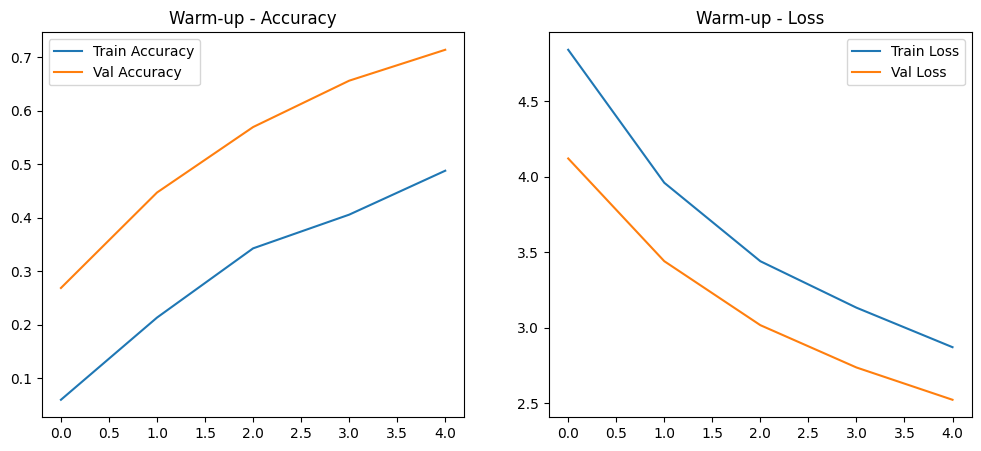

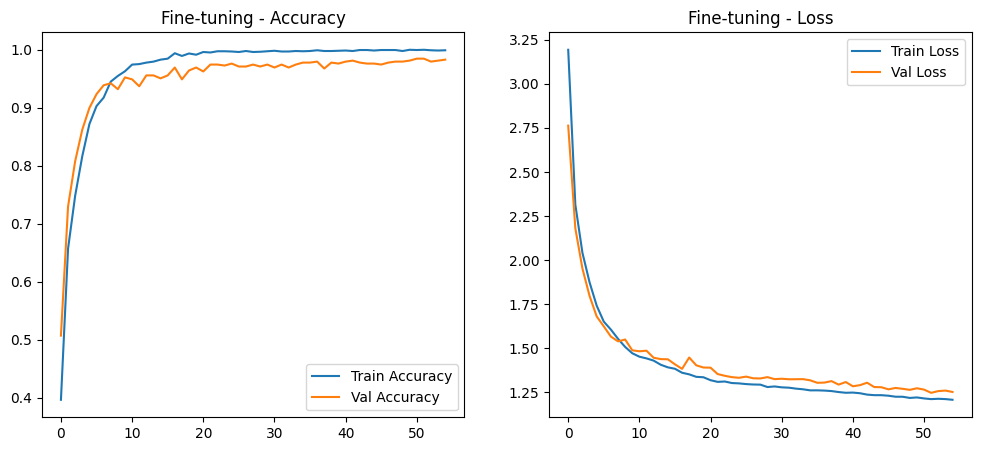

In [ ]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

plot_history(history_warmup, title="Warm-up")
plot_history(history_finetune, title="Fine-tuning")


# conclusion

In [13]:
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='fine_label',
    target_size=(IMG_RAW_H, IMG_RAW_W),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=lista_classi,
    shuffle=False
)

Found 2485 validated image filenames belonging to 81 classes.


In [14]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 360ms/step - accuracy: 0.6841 - loss: 1.9215
Test Accuracy: 0.7288


In [ ]:
test_loss, test_accuracy = model2.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.8495 - loss: 1.7025
Test Accuracy: 0.8732
